---
title: "Exploratory Data Analysis"
format:
    html:
        code-fold: false
---

## Overview

This notebook explores the cleaned DC datasets ahead of the network analysis. We cover the structure of the street network, where restaurants sit and how strongly they cluster, where the population that generates delivery demand lives, where observed traffic volume concentrates, and how far a courier can reach from the restaurant core. Each section saves a high resolution figure to `outputs`.

## Imports

In [1]:
from pathlib import Path

import geopandas as gpd
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import osmnx as ox
import pandas as pd
from matplotlib.colors import LogNorm
from scipy.spatial import cKDTree

# paths
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
CLEAN = PROJECT_ROOT / "data" / "clean"
OUTPUTS = PROJECT_ROOT / "outputs"
OUTPUTS.mkdir(parents=True, exist_ok=True)

CRS_DC = "EPSG:26985"
AMENITY_COLORS = {"restaurant": "#5b8dd9", "fast_food": "#e07b54", "cafe": "#59a96a"}

# load clean data
G = ox.load_graphml(CLEAN / "dc_drive_clean.graphml")
pois = gpd.read_file(CLEAN / "dc_restaurants_clean.geojson")
tracts = gpd.read_file(CLEAN / "dc_tracts_clean.geojson")
edge_aadt = pd.read_csv(CLEAN / "dc_edge_aadt.csv")

nodes_gdf, edges_gdf = ox.graph_to_gdfs(G)
nodes_p = nodes_gdf.to_crs(CRS_DC)
edges_p = edges_gdf.to_crs(CRS_DC)
pois_p = pois.to_crs(CRS_DC)
tracts_p = tracts.to_crs(CRS_DC)
print(f"Graph: {len(G.nodes):,} nodes, {len(G.edges):,} edges")
print(f"POIs: {len(pois):,}, tracts: {len(tracts):,}, edges with AADT: {len(edge_aadt):,}")

Graph: 10,027 nodes, 26,938 edges
POIs: 2,043, tracts: 206, edges with AADT: 6,109


## Network Summary Statistics

In [2]:
# summary statistics for the street network
stats = ox.stats.basic_stats(G)
rows = [
    {"Statistic": "Nodes (intersections)", "Value": f"{stats['n']:,}"},
    {"Statistic": "Directed edges", "Value": f"{stats['m']:,}"},
    {"Statistic": "Average degree", "Value": f"{stats['k_avg']:.2f}"},
    {"Statistic": "Average streets per node", "Value": f"{stats['streets_per_node_avg']:.2f}"},
    {"Statistic": "Street segments", "Value": f"{stats['street_segment_count']:,}"},
    {"Statistic": "Total street length (km)", "Value": f"{stats['street_length_total'] / 1000:,.0f}"},
    {"Statistic": "Self loop proportion", "Value": f"{stats['self_loop_proportion']:.4f}"},
]
print(pd.DataFrame(rows).to_string(index=False))

               Statistic  Value
   Nodes (intersections) 10,027
          Directed edges 26,938
          Average degree   5.37
Average streets per node   3.29
         Street segments 16,367
Total street length (km)  1,928
    Self loop proportion 0.0042


As we can see from the table above, the network has 10,027 intersections joined by 26,938 directed edges, which works out to an average degree of 5.37. The average of 3.29 streets per node is typical of a planned grid city with frequent four-way intersections, and the low self loop proportion tells us the graph is behaving like a proper street network rather than a collection of odd geometries.

## Street Network and Speeds

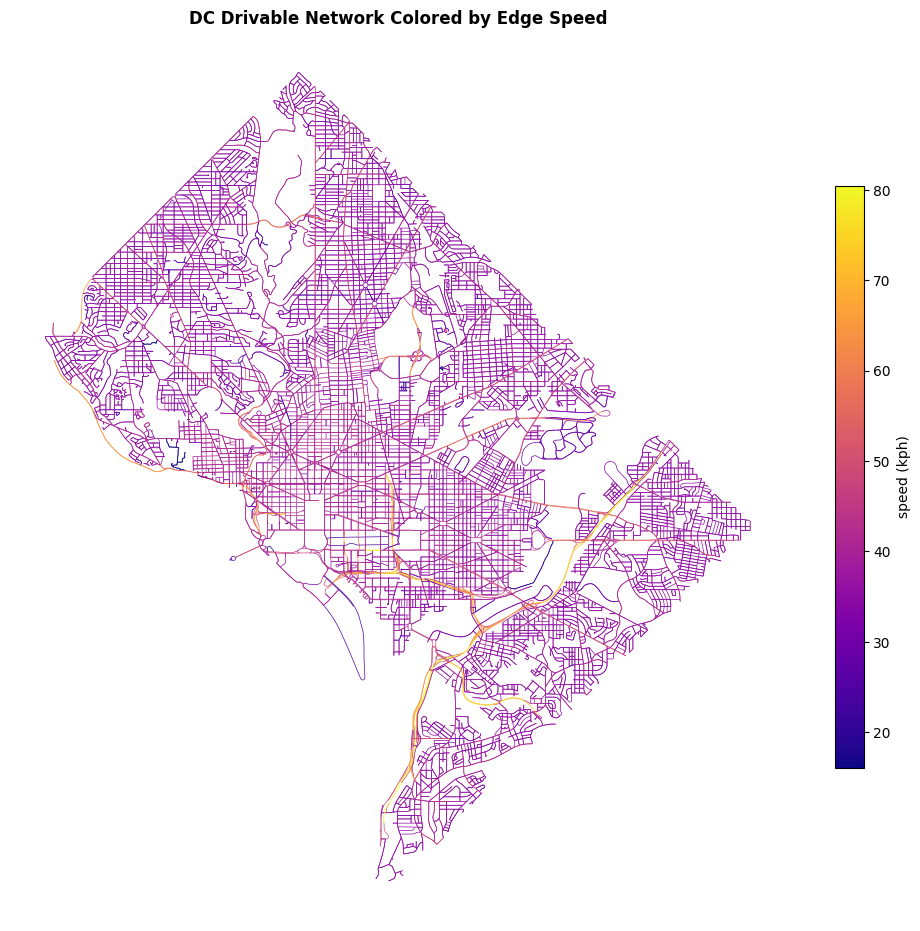

In [3]:
# map of the network with edges colored by assigned speed
fig, ax = plt.subplots(figsize=(10, 10))
edges_p.plot(ax=ax, column="speed_kph", cmap="plasma", linewidth=0.5, legend=True,
             legend_kwds={"label": "speed (kph)", "shrink": 0.6})
ax.set_title("DC Drivable Network Colored by Edge Speed", fontweight="bold")
ax.set_axis_off()
plt.tight_layout()
plt.savefig(OUTPUTS / "01_network_speeds.png", dpi=200, bbox_inches="tight")
plt.show()

As we can see from the map above, the speed structure follows the road hierarchy we would expect. The interstate segments in the southeast and the parkway corridors along the rivers carry the highest speeds, the diagonal avenues sit in the middle of the range, and the vast residential fabric fills in at around 35 kph. Deliveries will be won or lost on how quickly couriers can move between these slow local streets and the faster arterial spine.

## Node Connectivity

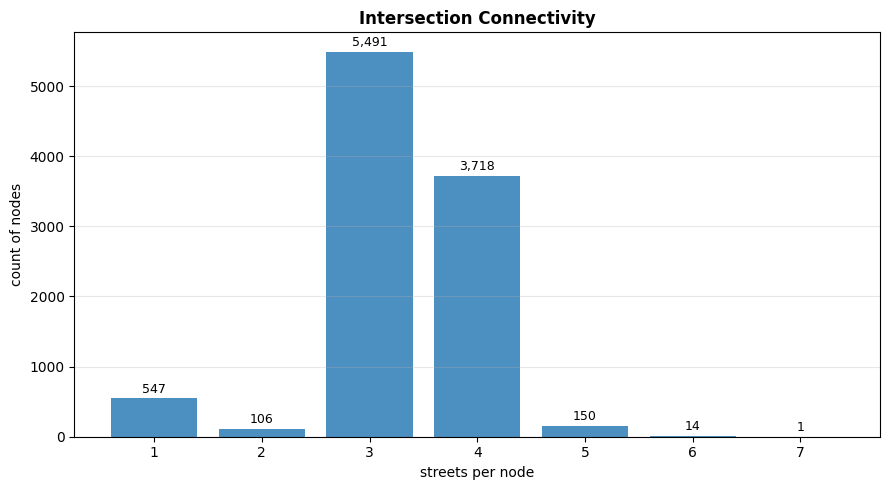

In [4]:
# distribution of streets per intersection
sc = nodes_gdf["street_count"].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(sc.index, sc.values, color="#2c7bb6", alpha=0.85)
for x, v in zip(sc.index, sc.values):
    ax.text(x, v + 40, f"{v:,}", ha="center", va="bottom", fontsize=9)
ax.set_xlabel("streets per node")
ax.set_ylabel("count of nodes")
ax.set_title("Intersection Connectivity", fontweight="bold")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUTS / "02_street_counts.png", dpi=200)
plt.show()

As we can see from the plot above, most intersections connect three or four streets, which reflects the L'Enfant grid, and dead ends are comparatively rare. From a routing point of view this is a forgiving topology, because a courier blocked on one segment usually has an immediate parallel alternative. The question for the bottleneck analysis is where that redundancy runs out, most obviously at the river crossings.

## Restaurant Spatial Distribution

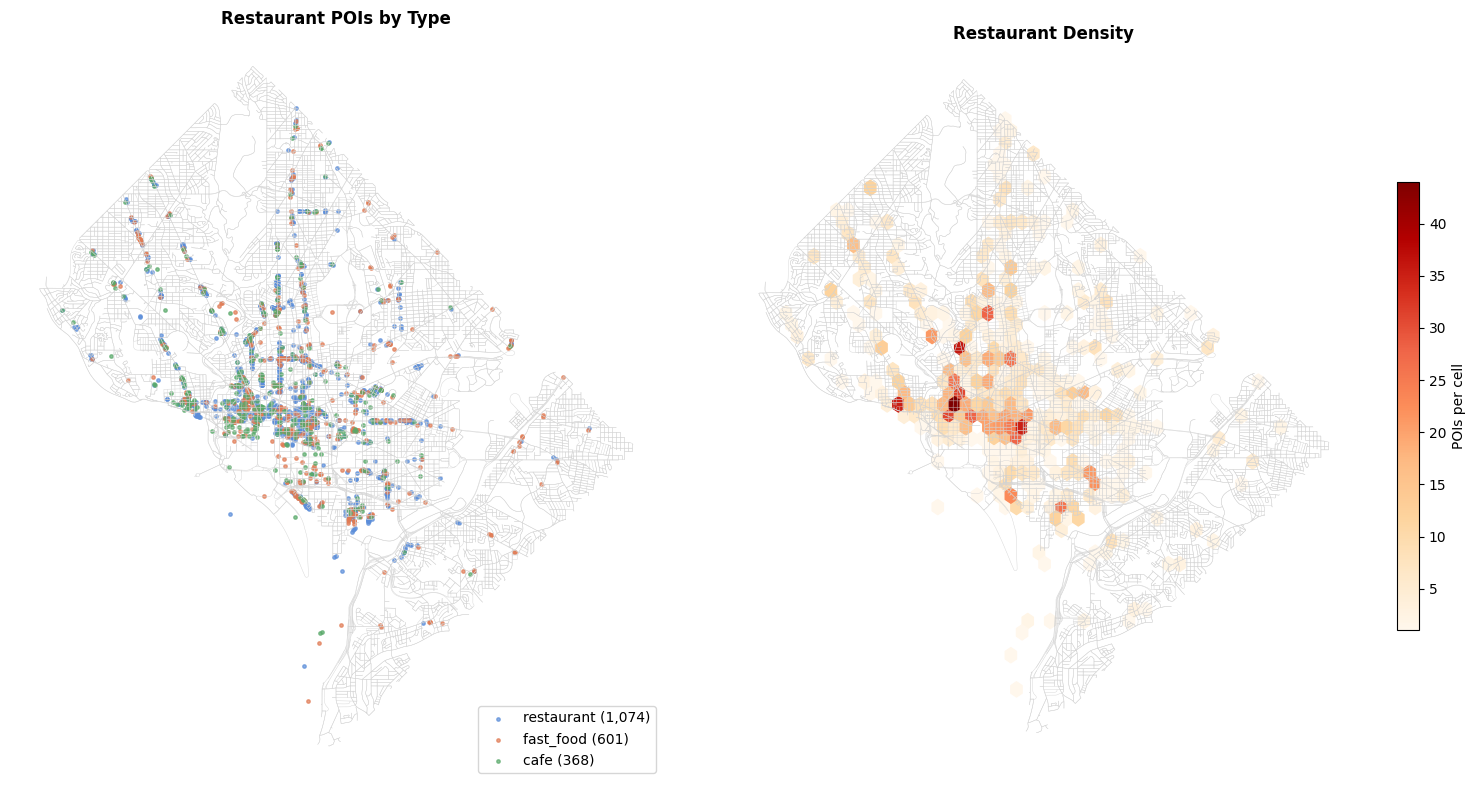

In [5]:
# where the restaurants are, by type and by density
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

edges_p.plot(ax=axes[0], color="lightgray", linewidth=0.3)
for amenity, color in AMENITY_COLORS.items():
    sub = pois_p[pois_p["amenity"] == amenity]
    axes[0].scatter(sub.geometry.x, sub.geometry.y, s=6, color=color, alpha=0.7, label=f"{amenity} ({len(sub):,})")
axes[0].legend(loc="lower right")
axes[0].set_title("Restaurant POIs by Type", fontweight="bold")
axes[0].set_axis_off()

edges_p.plot(ax=axes[1], color="lightgray", linewidth=0.3)
hb = axes[1].hexbin(pois_p.geometry.x, pois_p.geometry.y, gridsize=45, cmap="OrRd", mincnt=1)
plt.colorbar(hb, ax=axes[1], label="POIs per cell", shrink=0.6)
axes[1].set_title("Restaurant Density", fontweight="bold")
axes[1].set_axis_off()

plt.tight_layout()
plt.savefig(OUTPUTS / "03_restaurant_distribution.png", dpi=200, bbox_inches="tight")
plt.show()

As we can see from the maps above, the restaurant supply is anything but uniform. Full service restaurants dominate the count, and the density panel shows sharp concentrations downtown and along the 14th Street, U Street, H Street, and Georgetown corridors. Large areas east of the Anacostia River and in the residential northeast carry only scattered supply.

## Restaurant Clustering

Observed mean NN distance: 47 m
Expected under randomness: 147 m
Clark-Evans R: 0.32 (R < 1 means clustered)


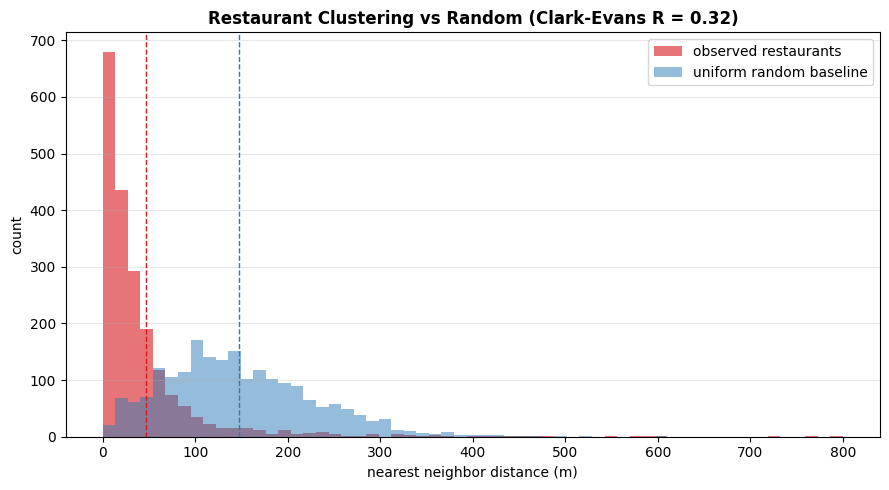

In [6]:
# quantify clustering with nearest neighbor distances against a uniform random baseline
xy = np.column_stack([pois_p.geometry.x, pois_p.geometry.y])
tree = cKDTree(xy)
d_obs, _ = tree.query(xy, k=2)
nn_obs = d_obs[:, 1]

# uniform random points inside the DC boundary, same count
boundary = tracts_p.union_all()
rng = np.random.default_rng(42)
minx, miny, maxx, maxy = boundary.bounds
pts = []
while len(pts) < len(xy):
    cand = np.column_stack([rng.uniform(minx, maxx, 5000), rng.uniform(miny, maxy, 5000)])
    inside = gpd.points_from_xy(cand[:, 0], cand[:, 1]).within(boundary)
    pts.extend(cand[inside].tolist())
rand_xy = np.array(pts[: len(xy)])
d_rand, _ = cKDTree(rand_xy).query(rand_xy, k=2)
nn_rand = d_rand[:, 1]

# Clark-Evans ratio, observed mean nearest neighbor distance over the expected distance under complete spatial randomness
area_m2 = tracts_p.area.sum()
expected = 0.5 / np.sqrt(len(xy) / area_m2)
R = nn_obs.mean() / expected
print(f"Observed mean NN distance: {nn_obs.mean():.0f} m")
print(f"Expected under randomness: {expected:.0f} m")
print(f"Clark-Evans R: {R:.2f} (R < 1 means clustered)")

fig, ax = plt.subplots(figsize=(9, 5))
bins = np.linspace(0, 800, 60)
ax.hist(nn_obs, bins=bins, color="#d7191c", alpha=0.6, label="observed restaurants")
ax.hist(nn_rand, bins=bins, color="#2c7bb6", alpha=0.5, label="uniform random baseline")
ax.axvline(nn_obs.mean(), color="#d7191c", linestyle="--", linewidth=1)
ax.axvline(nn_rand.mean(), color="#2c7bb6", linestyle="--", linewidth=1)
ax.set_xlabel("nearest neighbor distance (m)")
ax.set_ylabel("count")
ax.set_title(f"Restaurant Clustering vs Random (Clark-Evans R = {R:.2f})", fontweight="bold")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUTS / "04_restaurant_clustering.png", dpi=200)
plt.show()

As we can see from the histogram above, the observed nearest neighbor distances sit far to the left of the uniform baseline. The mean observed spacing is 47 m against an expected 147 m under complete spatial randomness, giving a Clark-Evans ratio of 0.32. This is strong quantitative confirmation that DC restaurants cluster, consistent with the agglomeration mechanism documented for Milan by Leonardi and Moretti (2023).

## Demand Heatmap and the Supply Mismatch

Top 10 tracts hold 37.2% of restaurants but 4.1% of population
Tract-level correlation between population and restaurant count: -0.09


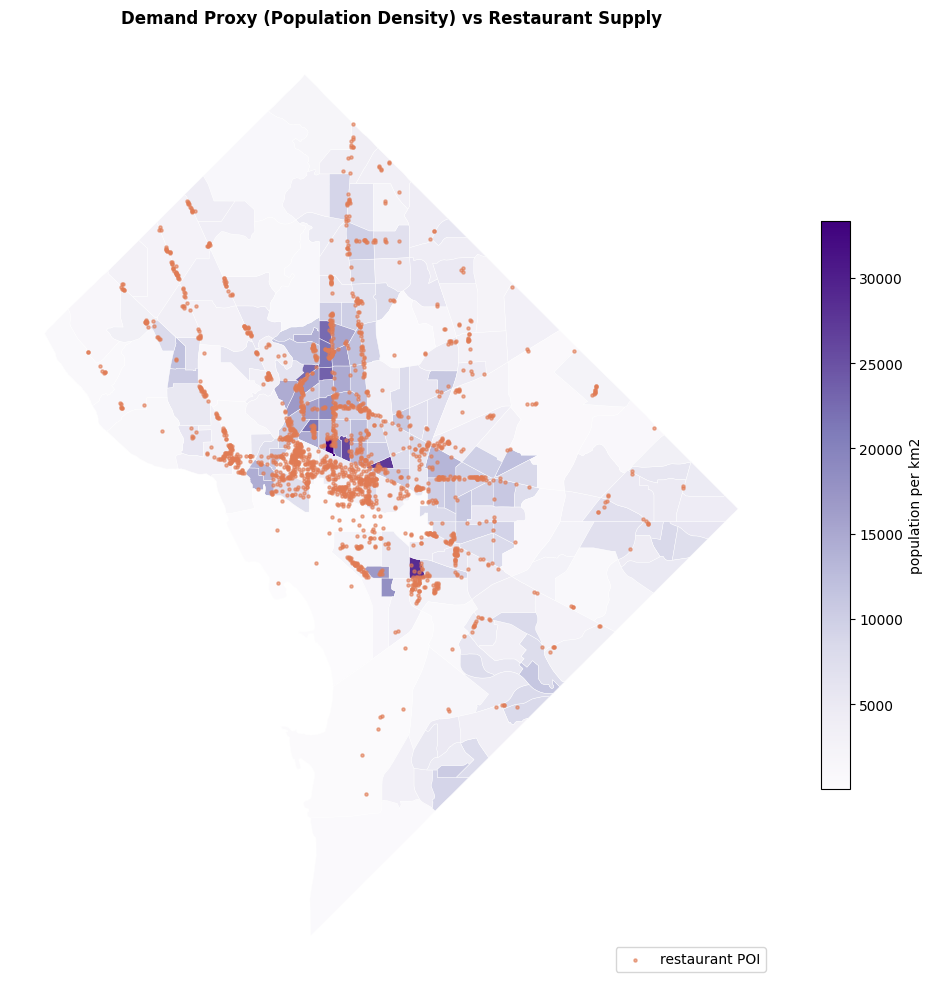

In [7]:
# population density choropleth with the restaurant supply on top
joined = gpd.sjoin(pois_p[["geometry"]], tracts_p[["geoid", "geometry"]], predicate="within")
rest_per_tract = joined.groupby("geoid").size().rename("n_restaurants")
tracts_p = tracts_p.merge(rest_per_tract, on="geoid", how="left")
tracts_p["n_restaurants"] = tracts_p["n_restaurants"].fillna(0)

top10 = tracts_p.nlargest(10, "n_restaurants")
share_rest = top10["n_restaurants"].sum() / tracts_p["n_restaurants"].sum()
share_pop = top10["population"].sum() / tracts_p["population"].sum()
corr = tracts_p[["population", "n_restaurants"]].corr().iloc[0, 1]
print(f"Top 10 tracts hold {100 * share_rest:.1f}% of restaurants but {100 * share_pop:.1f}% of population")
print(f"Tract-level correlation between population and restaurant count: {corr:.2f}")

fig, ax = plt.subplots(figsize=(10, 10))
tracts_p.plot(ax=ax, column="pop_density_km2", cmap="Purples", edgecolor="white", linewidth=0.3,
              legend=True, legend_kwds={"label": "population per km2", "shrink": 0.6})
ax.scatter(pois_p.geometry.x, pois_p.geometry.y, s=5, color="#e07b54", alpha=0.6, label="restaurant POI")
ax.legend(loc="lower right")
ax.set_title("Demand Proxy (Population Density) vs Restaurant Supply", fontweight="bold")
ax.set_axis_off()
plt.tight_layout()
plt.savefig(OUTPUTS / "05_demand_heatmap.png", dpi=200, bbox_inches="tight")
plt.show()

As we can see from the map above, the supply and the demand proxy do not live in the same places. The ten most restaurant-dense tracts hold 37.2 percent of all restaurants but only 4.1 percent of the population, and the tract-level correlation between population and restaurant count is effectively zero at -0.09. Delivery in DC is therefore structurally a transport problem, because the food is made downtown and in the northwest corridors while much of the demand sleeps elsewhere.

## Traffic Volume on the Network

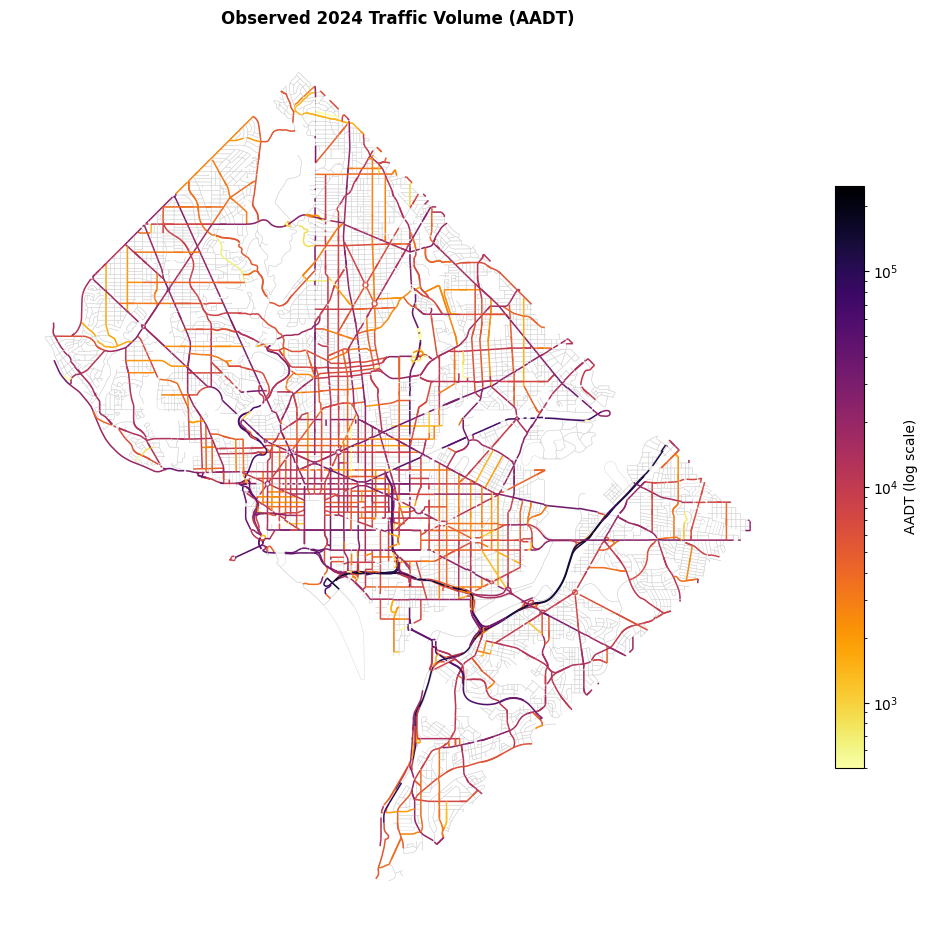

Busiest edge AADT: 164,773


In [8]:
# observed 2024 AADT drawn over the full network
edges_p_key = edges_p.reset_index()
aadt_map = edge_aadt.set_index(["u", "v", "key"])["aadt"]
edges_p_key["aadt"] = edges_p_key.set_index(["u", "v", "key"]).index.map(aadt_map)
with_aadt = edges_p_key[edges_p_key["aadt"].notna()]

fig, ax = plt.subplots(figsize=(10, 10))
edges_p.plot(ax=ax, color="lightgray", linewidth=0.3)
with_aadt.plot(ax=ax, column="aadt", cmap="inferno_r", linewidth=1.1, norm=LogNorm(vmin=500, vmax=250000),
               legend=True, legend_kwds={"label": "AADT (log scale)", "shrink": 0.6})
ax.set_title("Observed 2024 Traffic Volume (AADT)", fontweight="bold")
ax.set_axis_off()
plt.tight_layout()
plt.savefig(OUTPUTS / "06_traffic_aadt.png", dpi=200, bbox_inches="tight")
plt.show()
print(f"Busiest edge AADT: {with_aadt['aadt'].max():,.0f}")

As we can see from the map above, observed volume concentrates exactly where the network narrows. The heaviest edges are the freeway segments and the bridges over the Potomac and the Anacostia, with the busiest monitored edge carrying an AADT of 164,773. These crossings are natural candidates for the bottleneck analysis in the next notebook, because they combine high observed load with a scarcity of parallel alternatives.

## Courier Reach from the Restaurant Core

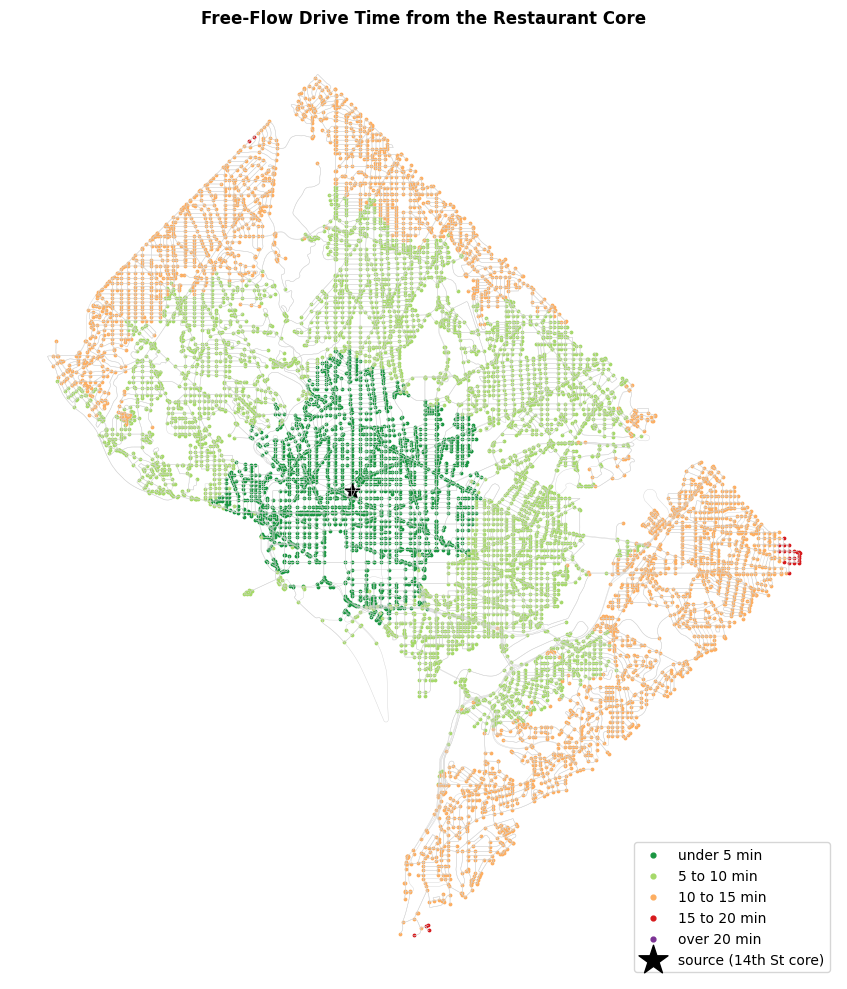

under 5 min: 2,327 nodes (23.2%)
5 to 10 min: 4,498 nodes (44.9%)
10 to 15 min: 3,173 nodes (31.6%)
15 to 20 min: 28 nodes (0.3%)
over 20 min: 0 nodes (0.0%)


In [9]:
# travel time from the restaurant core to every node, a first look at delivery reach
# source is the network node nearest the densest restaurant hexbin cell downtown
core_lon, core_lat = -77.032, 38.907
d2 = (nodes_gdf.geometry.x - core_lon) ** 2 + (nodes_gdf.geometry.y - core_lat) ** 2
source = d2.idxmin()
times = nx.single_source_dijkstra_path_length(G, source, weight="travel_time")
tt_min = pd.Series(times) / 60

bins = [0, 5, 10, 15, 20, np.inf]
labels = ["under 5 min", "5 to 10 min", "10 to 15 min", "15 to 20 min", "over 20 min"]
colors = ["#1a9641", "#a6d96a", "#fdae61", "#d7191c", "#7b3294"]
node_bin = pd.cut(tt_min.reindex(nodes_gdf.index), bins=bins, labels=labels)

fig, ax = plt.subplots(figsize=(10, 10))
edges_p.plot(ax=ax, color="lightgray", linewidth=0.3)
for label, color in zip(labels, colors):
    sel = nodes_p[node_bin == label]
    ax.scatter(sel.geometry.x, sel.geometry.y, s=3, color=color, label=label)
src_pt = nodes_p.loc[[source]]
ax.scatter(src_pt.geometry.x, src_pt.geometry.y, s=120, color="black", marker="*", label="source (14th St core)")
ax.legend(loc="lower right", markerscale=2)
ax.set_title("Free-Flow Drive Time from the Restaurant Core", fontweight="bold")
ax.set_axis_off()
plt.tight_layout()
plt.savefig(OUTPUTS / "07_courier_reach.png", dpi=200, bbox_inches="tight")
plt.show()

for label in labels:
    n = (node_bin == label).sum()
    print(f"{label}: {n:,} nodes ({100 * n / len(nodes_gdf):.1f}%)")

As we can see from the map above, free-flow reach from the 14th Street core is generous. About 23 percent of intersections are reachable within five minutes, 68 percent within ten, and effectively the whole District within fifteen. The catch is that these are free-flow times built from imputed speeds, so peak-hour congestion and pickup and dropoff overheads will compress this picture substantially. The gradient also runs against the demand map, since the areas beyond the ten minute band are exactly the population-dense areas east of the river.

## Figure Inventory

In [10]:
# everything written to outputs
for f in sorted(OUTPUTS.glob("*.png")):
    print(f"{f.name}  ({f.stat().st_size / 1e6:.1f} MB)")

01_network_speeds.png  (1.1 MB)
02_street_counts.png  (0.1 MB)
03_restaurant_distribution.png  (1.3 MB)
04_restaurant_clustering.png  (0.1 MB)
05_demand_heatmap.png  (0.4 MB)
06_traffic_aadt.png  (0.9 MB)
07_courier_reach.png  (1.3 MB)
08_bottleneck_edges.png  (0.7 MB)
09_renovation_experiment.png  (0.1 MB)
10_closure_robustness.png  (0.1 MB)


The EDA gives us a consistent picture. The network is dense and well connected but funnels through a small set of river crossings, restaurants cluster tightly in a handful of corridors, and the population that generates demand is spread far beyond those corridors. All seven figures are saved at high resolution in `outputs` and feed directly into the network analysis notebook.